# Item-Item Collaborative Filtering

## Learning Objectives

1. **Explain** the key scalability advantage of item-item over user-user CF
2. **Define** adjusted cosine similarity between items
3. **Derive** the rating prediction formula using item neighbourhood
4. **Describe** when to precompute item similarities (offline) vs when to compute on demand
5. **Implement** item-item CF with adjusted cosine similarity


## Problem Statement

### Scalability of User-User CF

User-user CF computes pairwise user similarities — $O(n_u^2)$ where $n_u$ is the number of users. For Amazon or Netflix with $10^8$ users this is $10^{16}$ comparisons — infeasible.

### Item-Item CF

Instead of comparing users, compare **items**. Key advantages:
- $n_i \ll n_u$ in most systems (items = $10^5$, users = $10^8$)
- Item similarities are **stable over time** (Matrix A is always similar to Matrix B regardless of new users), so we can precompute and cache them
- Prediction at query time requires only a **table lookup** (no recomputation)

### Adjusted Cosine Similarity

For items $i$ and $j$, compute cosine similarity over users who rated **both**, subtracting each user's mean rating to correct for rating scale biases:
$$\text{sim}(i, j) = \frac{\sum_{u \in U_{ij}} (r_{ui} - \bar{r}_u)(r_{uj} - \bar{r}_u)}{\sqrt{\sum_{u \in U_{ij}}(r_{ui}-\bar{r}_u)^2}\,\sqrt{\sum_{u \in U_{ij}}(r_{uj}-\bar{r}_u)^2}}$$
where $U_{ij}$ = users who rated both $i$ and $j$.


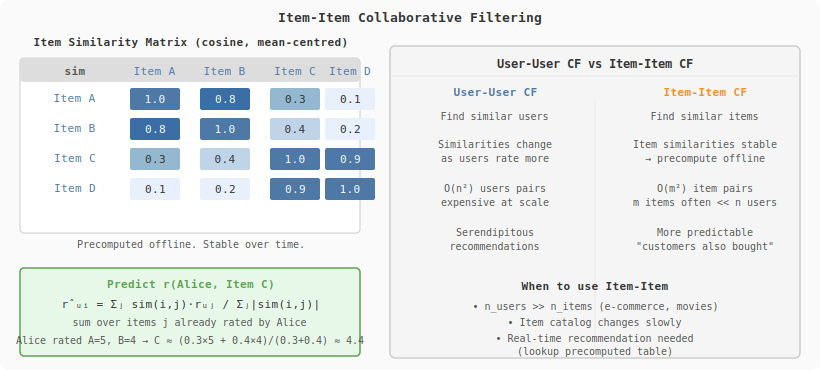

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="370" font-family="monospace" font-size="12">
  <rect width="820" height="370" fill="#fafafa" rx="8"/>
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Item-Item Collaborative Filtering</text>

  <!-- Item similarity matrix (left) -->
  <text x="190" y="46" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">Item Similarity Matrix (cosine, mean-centred)</text>
  <rect x="20" y="58" width="340" height="175" rx="4" fill="white" stroke="#ccc" stroke-width="1"/>
  <rect x="20" y="58" width="340" height="24" fill="#ddd" rx="4"/>
  <text x="75"  y="75" text-anchor="middle" fill="#555" font-size="11" font-weight="bold">sim</text>
  <text x="155" y="75" text-anchor="middle" fill="#4e79a7" font-size="11">Item A</text>
  <text x="225" y="75" text-anchor="middle" fill="#4e79a7" font-size="11">Item B</text>
  <text x="295" y="75" text-anchor="middle" fill="#4e79a7" font-size="11">Item C</text>
  <text x="350" y="75" text-anchor="middle" fill="#4e79a7" font-size="11">Item D</text>

  <text x="75" y="102" text-anchor="middle" fill="#4e79a7" font-size="11">Item A</text>
  <rect x="130" y="88" width="50" height="22" rx="2" fill="#4e79a7"/><text x="155" y="103" text-anchor="middle" fill="white" font-size="11">1.0</text>
  <rect x="200" y="88" width="50" height="22" rx="2" fill="#3a6ea5"/><text x="225" y="103" text-anchor="middle" fill="white" font-size="11">0.8</text>
  <rect x="270" y="88" width="50" height="22" rx="2" fill="#94b8d0"/><text x="295" y="103" text-anchor="middle" fill="#333" font-size="11">0.3</text>
  <rect x="325" y="88" width="50" height="22" rx="2" fill="#e8f0fb"/><text x="350" y="103" text-anchor="middle" fill="#333" font-size="11">0.1</text>

  <text x="75" y="132" text-anchor="middle" fill="#4e79a7" font-size="11">Item B</text>
  <rect x="130" y="118" width="50" height="22" rx="2" fill="#3a6ea5"/><text x="155" y="133" text-anchor="middle" fill="white" font-size="11">0.8</text>
  <rect x="200" y="118" width="50" height="22" rx="2" fill="#4e79a7"/><text x="225" y="133" text-anchor="middle" fill="white" font-size="11">1.0</text>
  <rect x="270" y="118" width="50" height="22" rx="2" fill="#c0d4e8"/><text x="295" y="133" text-anchor="middle" fill="#333" font-size="11">0.4</text>
  <rect x="325" y="118" width="50" height="22" rx="2" fill="#e8f0fb"/><text x="350" y="133" text-anchor="middle" fill="#333" font-size="11">0.2</text>

  <text x="75" y="162" text-anchor="middle" fill="#4e79a7" font-size="11">Item C</text>
  <rect x="130" y="148" width="50" height="22" rx="2" fill="#94b8d0"/><text x="155" y="163" text-anchor="middle" fill="#333" font-size="11">0.3</text>
  <rect x="200" y="148" width="50" height="22" rx="2" fill="#c0d4e8"/><text x="225" y="163" text-anchor="middle" fill="#333" font-size="11">0.4</text>
  <rect x="270" y="148" width="50" height="22" rx="2" fill="#4e79a7"/><text x="295" y="163" text-anchor="middle" fill="white" font-size="11">1.0</text>
  <rect x="325" y="148" width="50" height="22" rx="2" fill="#4e79a7"/><text x="350" y="163" text-anchor="middle" fill="white" font-size="11">0.9</text>

  <text x="75" y="192" text-anchor="middle" fill="#4e79a7" font-size="11">Item D</text>
  <rect x="130" y="178" width="50" height="22" rx="2" fill="#e8f0fb"/><text x="155" y="193" text-anchor="middle" fill="#333" font-size="11">0.1</text>
  <rect x="200" y="178" width="50" height="22" rx="2" fill="#e8f0fb"/><text x="225" y="193" text-anchor="middle" fill="#333" font-size="11">0.2</text>
  <rect x="270" y="178" width="50" height="22" rx="2" fill="#4e79a7"/><text x="295" y="193" text-anchor="middle" fill="white" font-size="11">0.9</text>
  <rect x="325" y="178" width="50" height="22" rx="2" fill="#4e79a7"/><text x="350" y="193" text-anchor="middle" fill="white" font-size="11">1.0</text>
  <text x="190" y="248" text-anchor="middle" fill="#555" font-size="10">Precomputed offline. Stable over time.</text>

  <!-- Prediction formula -->
  <rect x="20" y="268" width="340" height="88" rx="4" fill="#e8f8e8" stroke="#59a14f" stroke-width="1.5"/>
  <text x="190" y="288" text-anchor="middle" fill="#59a14f" font-size="11" font-weight="bold">Predict r(Alice, Item C)</text>
  <text x="190" y="308" text-anchor="middle" fill="#333" font-size="11">r̂ᵤᵢ = Σⱼ sim(i,j)·rᵤⱼ / Σⱼ|sim(i,j)|</text>
  <text x="190" y="326" text-anchor="middle" fill="#555" font-size="10">sum over items j already rated by Alice</text>
  <text x="190" y="344" text-anchor="middle" fill="#555" font-size="10">Alice rated A=5, B=4 → C ≈ (0.3×5 + 0.4×4)/(0.3+0.4) ≈ 4.4</text>

  <!-- Right: user-user vs item-item -->
  <rect x="390" y="46" width="410" height="312" rx="5" fill="#f5f5f5" stroke="#ccc" stroke-width="1.5"/>
  <text x="595" y="68" text-anchor="middle" fill="#333" font-size="12" font-weight="bold">User-User CF vs Item-Item CF</text>
  <line x1="390" y1="76" x2="800" y2="76" stroke="#ddd" stroke-width="0.5"/>

  <text x="495" y="96"  text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">User-User CF</text>
  <text x="705" y="96"  text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">Item-Item CF</text>
  <line x1="595" y1="100" x2="595" y2="350" stroke="#ddd" stroke-width="0.5"/>

  <text x="495" y="120" text-anchor="middle" fill="#555" font-size="10">Find similar users</text>
  <text x="705" y="120" text-anchor="middle" fill="#555" font-size="10">Find similar items</text>

  <text x="495" y="148" text-anchor="middle" fill="#555" font-size="10">Similarities change</text>
  <text x="495" y="162" text-anchor="middle" fill="#555" font-size="10">as users rate more</text>
  <text x="705" y="148" text-anchor="middle" fill="#555" font-size="10">Item similarities stable</text>
  <text x="705" y="162" text-anchor="middle" fill="#555" font-size="10">→ precompute offline</text>

  <text x="495" y="192" text-anchor="middle" fill="#555" font-size="10">O(n²) users pairs</text>
  <text x="495" y="206" text-anchor="middle" fill="#555" font-size="10">expensive at scale</text>
  <text x="705" y="192" text-anchor="middle" fill="#555" font-size="10">O(m²) item pairs</text>
  <text x="705" y="206" text-anchor="middle" fill="#555" font-size="10">m items often &lt;&lt; n users</text>

  <text x="495" y="236" text-anchor="middle" fill="#555" font-size="10">Serendipitous</text>
  <text x="495" y="250" text-anchor="middle" fill="#555" font-size="10">recommendations</text>
  <text x="705" y="236" text-anchor="middle" fill="#555" font-size="10">More predictable</text>
  <text x="705" y="250" text-anchor="middle" fill="#555" font-size="10">"customers also bought"</text>

  <text x="595" y="290" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">When to use Item-Item</text>
  <text x="595" y="310" text-anchor="middle" fill="#555" font-size="10">• n_users &gt;&gt; n_items (e-commerce, movies)</text>
  <text x="595" y="326" text-anchor="middle" fill="#555" font-size="10">• Item catalog changes slowly</text>
  <text x="595" y="342" text-anchor="middle" fill="#555" font-size="10">• Real-time recommendation needed</text>
  <text x="595" y="355" text-anchor="middle" fill="#555" font-size="10">  (lookup precomputed table)</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Why Adjusted Cosine?

Raw cosine of rating vectors ignores that different users use different rating scales. A user who rates everything 4–5 stars versus a user who rates everything 1–3 stars have different baselines. Subtracting $\bar{r}_u$ centres each user's ratings around 0, making comparisons meaningful.

### Prediction Formula

Given user $u$'s ratings on items $\mathcal{J}_u$ (already-rated items), predict $u$'s rating on item $i$:

$$\hat{r}_{ui} = \frac{\sum_{j \in \mathcal{N}_k(i) \cap \mathcal{J}_u} \text{sim}(i,j) \cdot r_{uj}}{\sum_{j \in \mathcal{N}_k(i) \cap \mathcal{J}_u} |\text{sim}(i,j)|}$$

**Note:** This is not mean-centred (unlike user-user CF) because the item similarity already accounts for user bias via adjusted cosine.

### Offline / Online Split

- **Offline (precompute):** Build the $n_i \times n_i$ item similarity matrix once. Update periodically (e.g. nightly).
- **Online (at query time):** Given user $u$ and target item $i$, look up similar items in the precomputed matrix, filter to items $u$ has rated, compute weighted average.

This makes item-item CF suitable for **real-time** recommendation (microsecond response).


## Algorithm Steps

**Offline:**
1. For each pair of items $(i, j)$: compute adjusted cosine over users who rated both
2. Store top-$k$ similar items per item

**Online (predict $r_{ui}$):**
1. Look up $\mathcal{N}_k(i)$ — top-$k$ items most similar to $i$
2. Filter to items user $u$ has already rated: $S = \mathcal{N}_k(i) \cap \mathcal{J}_u$
3. Compute $\hat{r}_{ui} = \frac{\sum_{j\in S} \text{sim}(i,j)\cdot r_{uj}}{\sum_{j\in S}|\text{sim}(i,j)|}$


In [2]:
import numpy as np
from collections import defaultdict


def cosine_similarity_items(ratings, item_a, item_b):
    """
    Adjusted cosine similarity between items a and b.
    Uses users who rated BOTH items; subtracts per-user mean.

    ratings : dict {user: {item: rating}}
    """
    # Find users who rated both items
    users_a = {u for u, r in ratings.items() if item_a in r}
    users_b = {u for u, r in ratings.items() if item_b in r}
    common = users_a & users_b

    if len(common) < 2:
        return 0.0

    # Compute per-user mean (over all items they rated)
    def user_mean(u):
        return np.mean(list(ratings[u].values()))

    a_vals = np.array([ratings[u][item_a] - user_mean(u) for u in common])
    b_vals = np.array([ratings[u][item_b] - user_mean(u) for u in common])

    denom = np.linalg.norm(a_vals) * np.linalg.norm(b_vals)
    if denom == 0:
        return 0.0
    return float(np.dot(a_vals, b_vals) / denom)


def build_item_similarity(ratings, items):
    """Precompute all pairwise item similarities."""
    sim = {}
    item_list = sorted(items)
    for i, a in enumerate(item_list):
        for b in item_list[i+1:]:
            s = cosine_similarity_items(ratings, a, b)
            sim[(a, b)] = sim[(b, a)] = s
        sim[(a, a)] = 1.0
    return sim


def item_item_cf(ratings, item_sim, target_user, target_item, k=3):
    """
    Predict rating of target_user on target_item using item-item CF.

    Inputs
    ------
    ratings     : dict {user: {item: rating}}
    item_sim    : dict {(item_a, item_b): similarity}
    target_user : user to predict for
    target_item : item to predict
    k           : number of similar items to use

    Output
    ------
    float — predicted rating
    """
    user_ratings = ratings.get(target_user, {})
    if not user_ratings:
        return 3.0  # global mean fallback

    # Find k most similar items that target_user has already rated
    sims = []
    for item, rating in user_ratings.items():
        if item == target_item:
            continue
        s = item_sim.get((target_item, item), 0.0)
        sims.append((s, item, rating))

    sims.sort(key=lambda x: -abs(x[0]))
    neighbours = sims[:k]

    if not neighbours:
        return np.mean(list(user_ratings.values()))

    numerator   = sum(s * r for s, _, r in neighbours)
    denominator = sum(abs(s) for s, _, _ in neighbours)
    if denominator == 0:
        return np.mean(list(user_ratings.values()))
    return numerator / denominator


# ── Demo ──────────────────────────────────────────────────────────────────────
ratings = {
    "Alice": {"A": 5, "B": 4, "D": 2},
    "Bob":   {"B": 3, "C": 4, "D": 3},
    "Carol": {"A": 4, "C": 5, "D": 3},
    "Dave":  {"A": 2, "B": 1, "D": 5},
    "Eve":   {"A": 4, "B": 5, "C": 3},
}

all_items = {item for user_r in ratings.values() for item in user_r}
item_sim = build_item_similarity(ratings, all_items)

print("Adjusted cosine item similarity matrix:")
items_sorted = sorted(all_items)
print(f"{'':>6}", end="")
for item in items_sorted:
    print(f"{item:>8}", end="")
print()
for a in items_sorted:
    print(f"{a:>6}", end="")
    for b in items_sorted:
        print(f"{item_sim.get((a,b),0):>8.3f}", end="")
    print()

pred = item_item_cf(ratings, item_sim, "Alice", "C", k=3)
print(f"\nPredicted rating for Alice on Item C: {pred:.2f}")


Adjusted cosine item similarity matrix:
             A       B       C       D
     A   1.000   0.529   0.000  -0.834
     B   0.529   1.000  -0.965  -0.867
     C   0.000  -0.965   1.000  -0.965
     D  -0.834  -0.867  -0.965   1.000

Predicted rating for Alice on Item C: -3.00
